<a href="https://colab.research.google.com/github/alynch8888/FMS_BFieldModel/blob/alec_lynch/Combine_PKL_files.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Code Setup

In [2]:
#Imports
import pickle
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
#From import
from scipy.stats import norm
from scipy.optimize import curve_fit
from datetime import date

#Useful names that can be used elsewhere
today = date.today()


In [3]:
##Data pkl files##
data_pkl_array = [
    "DSMap.pkl",
    "PSMap.pkl"
]
##Helicalc pkl files##
N_arc        = list(range(1,8,1))
N_straight   = [12, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34]
N_interlayer = [56, 57]#, 58]
N_layer_1      = [56, 60, 63]
N_layer_2      = [56]
# print(list(range(1,8,1)))
helicalc_partial_pkl_array = (
    [f"Mu2e_V13.DS_region.standard-busbar.cond_N_{n}_arc.pkl"                  for n in N_arc] +
    [f"Mu2e_V13.DS_region.standard-busbar.cond_N_{n}_straight.pkl"             for n in N_straight] +
    [f"Mu2e_V13.DS_region.standard-helicalc.coil_{n}_interlayer.pkl"           for n in N_interlayer] +
    [f"Mu2e_V13.DS_region.standard-helicalc.coil_{n}_layer_1.pkl"              for n in N_layer_1] +
    [f"Mu2e_V13.DS_region.standard-helicalc.coil_{n}_layer_2.pkl"              for n in N_layer_2]
)

# print(set(filenames) == set(helicalc_partial_pkl_array))
##Solcalc pkl files##
N_PS_coil = list(range(55, 0, -1))
# N_DSCyFMSAll_coil = list(range(66, 0, -1))
# N_DSCyFMSAll_Jacobian_coil = list(range(66, 0, -1))
solcalc_partial_pkl_array = (
    [f"Mu2e_V13.SolCalc.DS_region.standard.coil_{n}.pkl" for n in N_PS_coil] #+
    # ["Mu2e_V13.SolCalc.D0S_region.standard.coils_1-66.pkl"
    #  ]
)
print(data_pkl_array)
print(helicalc_partial_pkl_array)
print(solcalc_partial_pkl_array)
# print(len(solcalc_partial_pkl_array))
# pkl_2_txt


data_path = "/content/drive/MyDrive/BFields/data"
helicalc_path = "/content/drive/MyDrive/BFields/data/Bmaps/helicalc_partial"
solcalc_path = "/content/drive/MyDrive/BFields/data/Bmaps/SolCalc_partial"

#Helicalc_Drive Check(Data path)#
print("Checking " + data_path + "...")
missing_data = [f for f in data_pkl_array if not os.path.exists(os.path.join(data_path, f))]
found_data   = [f for f in data_pkl_array if     os.path.exists(os.path.join(data_path, f))]
print(f"Data Files Found:   {len(found_data)}")
print(f"Data Files Missing: {len(missing_data)}")

#Helicalc Busbar Check(helicalc_partial path)#
print("Checking Helicalc " + helicalc_path + "...")
missing_helicalc = [g for g in helicalc_partial_pkl_array if not os.path.exists(os.path.join(helicalc_path, g))]
found_helicalc   = [g for g in helicalc_partial_pkl_array if     os.path.exists(os.path.join(helicalc_path, g))]
print(f"Helicalc Files Found:   {len(found_helicalc)}")
print(f"Helicalc Files Missing: {len(missing_helicalc)}")

#Solcalc Check(solcalc_partial#
print("Checking Solcalc " + solcalc_path + "...")
missing_solcalc = [h for h in solcalc_partial_pkl_array if not os.path.exists(os.path.join(solcalc_path, h))]
found_solcalc   = [h for h in solcalc_partial_pkl_array if     os.path.exists(os.path.join(solcalc_path, h))]
print(f"Solcalc Files Found:   {len(found_solcalc)}")
print(f"Solcalc Files Missing: {len(missing_solcalc)}")

##Directory Names##
DSMap_pkl = data_path + "/" + data_pkl_array[0]
PSMap_pkl = data_path + "/" + data_pkl_array[1]
Data_file = [data_path + "/" + q for q in data_pkl_array]
Helicalc_file = [helicalc_path + "/" + w for w in helicalc_partial_pkl_array]
Solcalc_file = [solcalc_path + "/" + e for e in solcalc_partial_pkl_array]
##Checks if all files are found##
if missing_data:
    print("\nMissing files:")
    for f in missing_data:
        print(f"  {f}")
if missing_helicalc:
    print("\nMissing files:")
    for g in missing_helicalc:
        print(f"  {g}")
if missing_solcalc:
    print("\nMissing files:")
    for h in missing_solcalc:
        print(f"  {h}")

['DSMap.pkl', 'PSMap.pkl']
['Mu2e_V13.DS_region.standard-busbar.cond_N_1_arc.pkl', 'Mu2e_V13.DS_region.standard-busbar.cond_N_2_arc.pkl', 'Mu2e_V13.DS_region.standard-busbar.cond_N_3_arc.pkl', 'Mu2e_V13.DS_region.standard-busbar.cond_N_4_arc.pkl', 'Mu2e_V13.DS_region.standard-busbar.cond_N_5_arc.pkl', 'Mu2e_V13.DS_region.standard-busbar.cond_N_6_arc.pkl', 'Mu2e_V13.DS_region.standard-busbar.cond_N_7_arc.pkl', 'Mu2e_V13.DS_region.standard-busbar.cond_N_12_straight.pkl', 'Mu2e_V13.DS_region.standard-busbar.cond_N_25_straight.pkl', 'Mu2e_V13.DS_region.standard-busbar.cond_N_26_straight.pkl', 'Mu2e_V13.DS_region.standard-busbar.cond_N_27_straight.pkl', 'Mu2e_V13.DS_region.standard-busbar.cond_N_28_straight.pkl', 'Mu2e_V13.DS_region.standard-busbar.cond_N_29_straight.pkl', 'Mu2e_V13.DS_region.standard-busbar.cond_N_30_straight.pkl', 'Mu2e_V13.DS_region.standard-busbar.cond_N_31_straight.pkl', 'Mu2e_V13.DS_region.standard-busbar.cond_N_32_straight.pkl', 'Mu2e_V13.DS_region.standard-busbar.co

# Script Definitions

In [4]:
##########Load pkl files into a readable format##########
def load_pkl(filepath):
    with open(filepath, "rb") as f:
        return pickle.load(f)

#Print pkl info
def pkl_2_txt(pkl_file):
    with open(pkl_file, 'rb') as f:
        data = pickle.load(f)
    print(data)

##########Print the xyz coordinates from the pkl files##########
def print_xyz_coord(filepath):
    # print(Data_file)
    for i, fpath in enumerate(filepath):
      df = load_pkl(fpath)
      # print(i, df.shape)
      print(f"/n{fpath}")
      for col in ['X','Y','Z']:
        print(f" {col}: {df[col].min()} to {df[col].max()}")

##########Sum Field Maps########## Does not drop R,Phi, BR, and BPhi
def sum_field_maps(filepath,filename,pklarray):
    coord_cols = ['X', 'Y', 'Z']
    field_cols = ['Bx', 'By', 'Bz']

    output_path = os.path.join(filepath, filename+".pkl")

    result = None
    for fname in pklarray:
        fpath = os.path.join(filepath, fname)
        df = load_pkl(fpath)

        # Rename field cols by position
        cols = df.columns.tolist()
        cols[3] = 'Bx'
        cols[4] = 'By'
        cols[5] = 'Bz'
        df.columns = cols

        if result is None:
            result = df
        else:
            merged = result.merge(df, on=coord_cols, how='outer', suffixes=('_a', '_b'))
            for col in field_cols:
                merged[col] = merged[f'{col}_a'].add(merged[f'{col}_b'], fill_value=0)
            result = merged[result.columns.tolist()]

    with open(output_path, "wb") as f:
        pickle.dump(result, f)

    txt_path = output_path.replace('.pkl', '.txt')
    # txt_path = os.path.join(filepath, filename+".txt")
    result.to_csv(txt_path, index=False)
    # result.to_csv(txt_path, sep='\t', index=False)

    print(f"Saved to {output_path}")
    print(f"Saved to {txt_path}")

##########Check if certain files exist##########
def check_file_existence(filepath,pkl_array):
    print("Checking " + filepath + "...")
    missing_data = [f for f in pkl_array if not os.path.exists(os.path.join(filepath, f))]
    found_data   = [f for f in pkl_array if     os.path.exists(os.path.join(filepath, f))]
    print(f"Data Files Found:   {len(found_data)}")
    print(f"Data Files Missing: {len(missing_data)}")
    if missing_data:
        print("\nMissing files:")
        for f in missing_data:
            print(f"  {f}")

##########Sum field maps with a shift on the x-coordinates##########
def sum_field_maps_w_shift(filepath, filename, pklarray, coord_shift=0.0):
    coord_cols = ['X', 'Y', 'Z']
    field_cols = ['Bx', 'By', 'Bz']

    output_path = os.path.join(filepath, filename + f"_x_{coord_shift}.pkl")

    result = None
    for fname in pklarray:
        fpath = os.path.join(filepath, fname)
        df = load_pkl(fpath)

        # Rename field cols by position
        cols = df.columns.tolist()
        cols[3] = 'Bx'
        cols[4] = 'By'
        cols[5] = 'Bz'
        df.columns = cols

        # Apply coordinate shift to X
        df['X'] = df['X'] + coord_shift


        if result is None:
            result = df
        else:
            merged = result.merge(df, on=coord_cols, how='outer', suffixes=('_a', '_b'))
            for col in field_cols:
                merged[col] = merged[f'{col}_a'].add(merged[f'{col}_b'], fill_value=0)
            result = merged[result.columns.tolist()]

    with open(output_path, "wb") as f:
        pickle.dump(result, f)

    txt_path = output_path.replace('.pkl', '.txt')
    result.to_csv(txt_path, index=False)

    print(f"Saved to {output_path}")
    print(f"Saved to {txt_path}")

##########Shift x-coordinates##########
def shift_x(filepath, filename, coord_shift):
    fpath = os.path.join(filepath, filename)
    df = load_pkl(fpath)

    df['X'] = df['X'] + coord_shift
    df['X'] = df['X'].round(3)
    output_path = os.path.join(filepath, filename.replace('.pkl', f'_x_{coord_shift}.pkl'))

    with open(output_path, 'wb') as f:
        pickle.dump(df, f)

    print(f"Saved to {output_path}")

##########Sum Field Maps (Drops R, Phi, Br, and Bphi; keeps X, Y, Z, Bx, By, Bz)##########
def sum_field_maps(fileoutput_path, filename, pklarray):
    coord_cols = ['X', 'Y', 'Z']
    field_cols = ['Bx', 'By', 'Bz']
    keep_cols = coord_cols + field_cols  # ['X', 'Y', 'Z', 'Bx', 'By', 'Bz']

    output_pkl = os.path.join(fileoutput_path, filename + ".pkl")
    output_csv = os.path.join(fileoutput_path, filename + ".txt")

    result = None
    for fpath in pklarray:
        df = load_pkl(fpath)

        cols = df.columns.tolist()
        cols[3], cols[4], cols[5] = 'Bx', 'By', 'Bz'
        df.columns = cols

        # Drop R, Phi, Br, Bphi
        df = df[keep_cols]

        if result is None:
            result = df
        else:
            merged = result.merge(df, on=coord_cols, how='outer', suffixes=('_a', '_b'))
            for col in field_cols:
                merged[col] = merged[f'{col}_a'].add(merged[f'{col}_b'], fill_value=0)
            result = merged[keep_cols]
            # result.loc[:, field_cols] = result[field_cols] / 1000

        # result[field_cols] = result[field_cols] / 1000

    with open(output_pkl, "wb") as f:
        pickle.dump(result, f)

    result.to_csv(output_csv, index=False)

    print(f"Saved to {output_pkl}")
    print(f"Saved to {output_csv}")

#Coordinate Shift from running helicalc_drive. Need to confirm this.
coord_shift = -3.896 #This one is the change from -1.2 to -5.096.
actual_shift = -3.904

##########Gaussian Fits##########
def gaussian(x, amplitude, mean, sigma):
    return amplitude * np.exp(-(x - mean)**2 / (2 * sigma**2))

def fit_and_plot_gaussian(data, ax, label, color='C0', bins=100, linthresh=1e-2):
    data = np.asarray(data)
    data = data[~np.isnan(data)]

    # Histogram (density=True so the Gaussian fit is on the same scale)
    counts, bin_edges = np.histogram(data, bins=bins, density=True)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Initial guesses: amplitude ~ peak, mean ~ data mean, sigma ~ data std
    p0 = [counts.max(), np.mean(data), np.std(data)]

    try:
        popt, pcov = curve_fit(gaussian, bin_centers, counts, p0=p0, maxfev=10000)
        amplitude, mean, sigma = popt
        perr = np.sqrt(np.diag(pcov))
    except RuntimeError:
        print(f"Fit failed for {label}")
        return None

    # Plot histogram
    ax.hist(data, bins=bins, density=True, alpha=0.5, color=color, label=f'{label} data')

    # Plot fit curve
    x_fit = np.linspace(bin_edges[0], bin_edges[-1], 1000)
    ax.plot(x_fit, gaussian(x_fit, *popt), color=color, linewidth=2,
             label=f'{label} fit: μ={mean:.4g}, σ={sigma:.4g}')

    ax.set_xscale("symlog", linthresh=linthresh)
    ax.set_xlabel(label)
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)

    return {'amplitude': amplitude, 'mean': mean, 'sigma': sigma,
            'amplitude_err': perr[0], 'mean_err': perr[1], 'sigma_err': perr[2]}

In [5]:
#Paths

DSMap_path = "/content/drive/MyDrive/BFields/data/"
Busbar_Sum_path = "/content/drive/MyDrive/BFields/data/Bmaps/helicalc_partial/"
Solcalc_Sum_path = "/content/drive/MyDrive/BFields/data/Bmaps/SolCalc_partial/"

Solcalc_test_path = "/content/drive/MyDrive/BFields/data/Bmaps/SolCalc_partial/Solcalc_Summed.pkl"
DS_Summed_pkl_path = "/content/drive/MyDrive/BFields/data/DS_Summed.pkl"

# Sum Field Maps Together



In [6]:
# def test(testname):
#   test = testname+".txt"
#   print(test)
#data_pkl_array
# sum_field_maps(data_path,"helicalc_drive_Summed data",data_pkl_array)<-Bad, do not use. Can erase this line but didn't.

# sum_field_maps(solcalc_path,"Solcalc_Summed",solcalc_partial_pkl_array)
# sum_field_maps(helicalc_path,"Busbar_Summed",helicalc_partial_pkl_array)

shift_x("/content/drive/MyDrive/BFields/data/","DSMap.pkl",coord_shift)
# shift_x("/content/drive/MyDrive/BFields/data/","DSMap.pkl",actual_shift)

/tmp/ipykernel_37091/740521868.py:4: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return pickle.load(f)


Saved to /content/drive/MyDrive/BFields/data/DSMap_x_-3.896.pkl


In [7]:
pkl_2_txt("/content/drive/MyDrive/BFields/data/DSMap_x_-3.896.pkl")
# pkl_2_txt("/content/drive/MyDrive/BFields/data/DSMap_x_-3.904.pkl")

             X    Y       Z           Bx           By          Bz         R  \
0       -5.096 -1.2   3.071  1284.125788  1307.100001  442.195248  1.697056   
1       -5.096 -1.2   3.096  1312.127380  1335.143291  410.874370  1.697056   
2       -5.096 -1.2   3.121  1339.646202  1362.701661  376.958648  1.697056   
3       -5.096 -1.2   3.146  1366.531533  1389.624290  340.379319  1.697056   
4       -5.096 -1.2   3.171  1392.610688  1415.737061  301.071838  1.697056   
...        ...  ...     ...          ...          ...         ...       ...   
4902084 -2.696  1.2  15.971   205.452081   204.896327  362.118995  1.697056   
4902085 -2.696  1.2  15.996   200.959435   200.443981  358.156213  1.697056   
4902086 -2.696  1.2  16.021   196.581608   196.105341  354.221831  1.697056   
4902087 -2.696  1.2  16.046   192.315417   191.877252  350.317143  1.697056   
4902088 -2.696  1.2  16.071   188.157767   187.756646  346.443323  1.697056   

              Phi           Br       Bphi  
0      

In [8]:
DSMap_path = "/content/drive/MyDrive/BFields/data/"
Busbar_Sum_path = "/content/drive/MyDrive/BFields/data/Bmaps/helicalc_partial/"
Solcalc_Sum_path = "/content/drive/MyDrive/BFields/data/Bmaps/SolCalc_partial/"

Solcalc_test_path = "/content/drive/MyDrive/BFields/data/Bmaps/SolCalc_partial/Solcalc_Summed.pkl"
DS_Summed_pkl_path = "/content/drive/MyDrive/BFields/data/DS_Summed.pkl"
DS_Sum_pkl_array = ("DSMap_x_-3.896.pkl" #"DSMap.pkl"
                    ,"Busbar_Summed.pkl",
                    "Solcalc_Summed.pkl")

DS_Sum_path_array = (
    DSMap_path + DS_Sum_pkl_array[0],
    Busbar_Sum_path + DS_Sum_pkl_array[1],
    Solcalc_Sum_path + DS_Sum_pkl_array[2]
)



# Call after definition
sum_field_maps(DSMap_path,"DS_Summed",DS_Sum_path_array)

Saved to /content/drive/MyDrive/BFields/data/DS_Summed.pkl
Saved to /content/drive/MyDrive/BFields/data/DS_Summed.txt


In [9]:

print("Solcalc_Summed.pkl")
pkl_2_txt(Solcalc_test_path)
print("Busbar Summed")
pkl_2_txt("/content/drive/MyDrive/BFields/data/Bmaps/helicalc_partial/Busbar_Summed.pkl")
print("DSMap.pkl")
pkl_2_txt("/content/drive/MyDrive/BFields/data/DSMap_x_-3.896.pkl")
print("DS_Summed.pkl")
pkl_2_txt(DS_Summed_pkl_path)

Solcalc_Summed.pkl
             X    Y       Z        Bx        By        Bz
0       -5.096 -1.2   3.071 -0.024137 -0.022408 -0.003617
1       -5.096 -1.2   3.096 -0.024238 -0.022516 -0.003246
2       -5.096 -1.2   3.121 -0.024330 -0.022615 -0.002869
3       -5.096 -1.2   3.146 -0.024413 -0.022704 -0.002487
4       -5.096 -1.2   3.171 -0.024485 -0.022784 -0.002101
...        ...  ...     ...       ...       ...       ...
4902084 -2.696  1.2  15.971 -0.000091  0.000090  0.000918
4902085 -2.696  1.2  15.996 -0.000091  0.000090  0.000914
4902086 -2.696  1.2  16.021 -0.000091  0.000089  0.000911
4902087 -2.696  1.2  16.046 -0.000090  0.000089  0.000907
4902088 -2.696  1.2  16.071 -0.000090  0.000088  0.000904

[4902089 rows x 6 columns]
Busbar Summed
             X    Y       Z        Bx        By        Bz
0       -5.096 -1.2   3.071  0.062237  0.062791 -0.011680
1       -5.096 -1.2   3.096  0.062901  0.063459 -0.014591
2       -5.096 -1.2   3.121  0.063463  0.064025 -0.017669
3       -5.

In [10]:
for fpath in DS_Sum_path_array:
    try:
        df = load_pkl(fpath)
        print(f"OK: {fpath} — {df.shape}")
    except Exception as e:
        print(f"ERROR: {fpath} — {e}")

OK: /content/drive/MyDrive/BFields/data/DSMap_x_-3.896.pkl — (4902089, 10)
OK: /content/drive/MyDrive/BFields/data/Bmaps/helicalc_partial/Busbar_Summed.pkl — (4902089, 6)
OK: /content/drive/MyDrive/BFields/data/Bmaps/SolCalc_partial/Solcalc_Summed.pkl — (4902089, 6)


In [11]:
dfs = []
for fpath in DS_Sum_path_array:
    df = load_pkl(fpath)
    cols = df.columns.tolist()
    cols[3], cols[4], cols[5] = 'Bx', 'By', 'Bz'
    df.columns = cols
    df = df[['X', 'Y', 'Z', 'Bx', 'By', 'Bz']]
    dfs.append(df)
    print(f"{fpath}")
    print(f"  shape: {df.shape}")
    print(f"  X: {df['X'].min()} to {df['X'].max()}")
    print(f"  Y: {df['Y'].min()} to {df['Y'].max()}")
    print(f"  Z: {df['Z'].min()} to {df['Z'].max()}")

# Check overlap between first two
common = dfs[0].merge(dfs[1], on=['X','Y','Z'], how='inner')
print(f"\nOverlap between file 0 and 1: {common.shape[0]} rows")

common2 = dfs[0].merge(dfs[2], on=['X','Y','Z'], how='inner')
print(f"Overlap between file 0 and 2: {common2.shape[0]} rows")


# print_xyz_coord(Data_file)
# print('#####################')
# print_xyz_coord(Helicalc_file)
# print('#####################')
# print_xyz_coord(Solcalc_file)
# print('#####################')
# print_xyz_coord()

/content/drive/MyDrive/BFields/data/DSMap_x_-3.896.pkl
  shape: (4902089, 6)
  X: -5.096 to -2.696
  Y: -1.2 to 1.2
  Z: 3.071 to 16.071
/content/drive/MyDrive/BFields/data/Bmaps/helicalc_partial/Busbar_Summed.pkl
  shape: (4902089, 6)
  X: -5.096 to -2.696
  Y: -1.2 to 1.2
  Z: 3.071 to 16.071
/content/drive/MyDrive/BFields/data/Bmaps/SolCalc_partial/Solcalc_Summed.pkl
  shape: (4902089, 6)
  X: -5.096 to -2.696
  Y: -1.2 to 1.2
  Z: 3.071 to 16.071

Overlap between file 0 and 1: 4902089 rows
Overlap between file 0 and 2: 4902089 rows


# Compare Combined Helicalc vs CVMFS

In [12]:
DS_Summed_txt_path = "/content/drive/MyDrive/BFields/data/DS_Summed.txt"
cvmfs_DSMap_txt_path = "/content/drive/MyDrive/BFields/data/cvmfs_Maps/DSMap.txt"

load_DS_Sum = load_pkl(DS_Summed_pkl_path)

# print(cvmfs_DSMap_txt_path)


cvmfs_data = np.loadtxt(
    cvmfs_DSMap_txt_path,
    skiprows=4,        # skip a header row
    comments='#',      # ignore lines starting with #
    delimiter=None,    # whitespace by default; use ',' for CSV-like
)

my_data = np.loadtxt(
    DS_Summed_txt_path,
    skiprows=1,        # skip a header row
    comments='#',      # ignore lines starting with #
    delimiter=",",    # whitespace by default; use ',' for CSV-like
)
print("cvmfs_data: XYZ(mm), BxByBx(Tesla)")
print(cvmfs_data)
print("my_data: XYZ(m), BxByBx(Gauss)")
print(my_data)

cvmfs_data: XYZ(mm), BxByBx(Tesla)
[[-5.09600000e+03 -1.20000000e+03  3.07100000e+03  1.28412579e-01
   1.30710000e-01  4.42195248e-02]
 [-5.09600000e+03 -1.20000000e+03  3.09600000e+03  1.31212738e-01
   1.33514329e-01  4.10874370e-02]
 [-5.09600000e+03 -1.20000000e+03  3.12100000e+03  1.33964620e-01
   1.36270166e-01  3.76958648e-02]
 ...
 [-2.69600000e+03  1.20000000e+03  1.60210000e+04  1.96581608e-02
   1.96105341e-02  3.54221831e-02]
 [-2.69600000e+03  1.20000000e+03  1.60460000e+04  1.92315417e-02
   1.91877252e-02  3.50317143e-02]
 [-2.69600000e+03  1.20000000e+03  1.60710000e+04  1.88157767e-02
   1.87756646e-02  3.46443323e-02]]
my_data: XYZ(m), BxByBx(Gauss)
[[-5.09600000e+00 -1.20000000e+00  3.07100000e+00  1.28416389e+03
   1.30714038e+03  4.42179951e+02]
 [-5.09600000e+00 -1.20000000e+00  3.09600000e+00  1.31216604e+03
   1.33518423e+03  4.10856533e+02]
 [-5.09600000e+00 -1.20000000e+00  3.12100000e+00  1.33968533e+03
   1.36274307e+03  3.76938111e+02]
 ...
 [-2.69600000e

In [13]:
# print(cvmfs_data,"\n","Break","\n",my_data)
# print(data[0,1])
# print(data[0,0])
z = [0,1,2,3,4,5]
# print("Test")
# for i in z:
#   print(data[i,0])

# print(load_DS_Sum)
# print("TEST")
# print(load_DS_Sum[0:1])

a = my_data #Note: My data uses Gauss and meters.
b = cvmfs_data #Note: CVMFS data uses Tesla and mm.
#Conversions
#1E4G=1T
#1000mm=1m
##########***Remember that cvmfs is initially in mm and Tesla***##########
cvmfs_coord = cvmfs_data[:,0:3]# This is initially in mm. We are using only one of these so there is not reason to change.
cvmfs_field = cvmfs_data[:,3:6]*1e4 #Unit Change to Gauss

#########***Remember that my_data is initially in m and Gauss***##########
mydata_coord = my_data[:,0:3]#/1e3 #Unit change to m. This change is not actually needed since the coordinates are the same. I use the coordinates from cvmfs, just because.
mydata_field = my_data[:,3:6]#/1e4 #Keep in Gauss for easier to look at values.

##########Everything should now be in m and Gauss##########
# print(cvmfs_data)
# print(cvmfs_coord)
# print(cvmfs_field)
sep = "######################### \n"
# print(sep)
# print(mydata_coord)
# print(mydata_field)
# print(sep)

field_diff = mydata_field - cvmfs_field
frac_error = field_diff/cvmfs_field
per_err = 100*frac_error
print(sep,"Field Difference(Gauss)")
print(field_diff.round(7))
print(sep,"Fractional Error")
print(frac_error.round(7))
# print(sep,"\n","Percent Error")
# print(per_err)


######################### 
 Field Difference(Gauss)
[[ 0.0381     0.0403831 -0.0152972]
 [ 0.0386621  0.0409428 -0.017837 ]
 [ 0.0391323  0.0414099 -0.0205372]
 ...
 [ 0.0006267  0.0006966  0.0038351]
 [ 0.0006183  0.0006889  0.0038065]
 [ 0.00061    0.0006814  0.0037781]]
######################### 
 Fractional Error
[[ 2.97e-05  3.09e-05 -3.46e-05]
 [ 2.95e-05  3.07e-05 -4.34e-05]
 [ 2.92e-05  3.04e-05 -5.45e-05]
 ...
 [ 3.20e-06  3.60e-06  1.08e-05]
 [ 3.20e-06  3.60e-06  1.09e-05]
 [ 3.20e-06  3.60e-06  1.09e-05]]


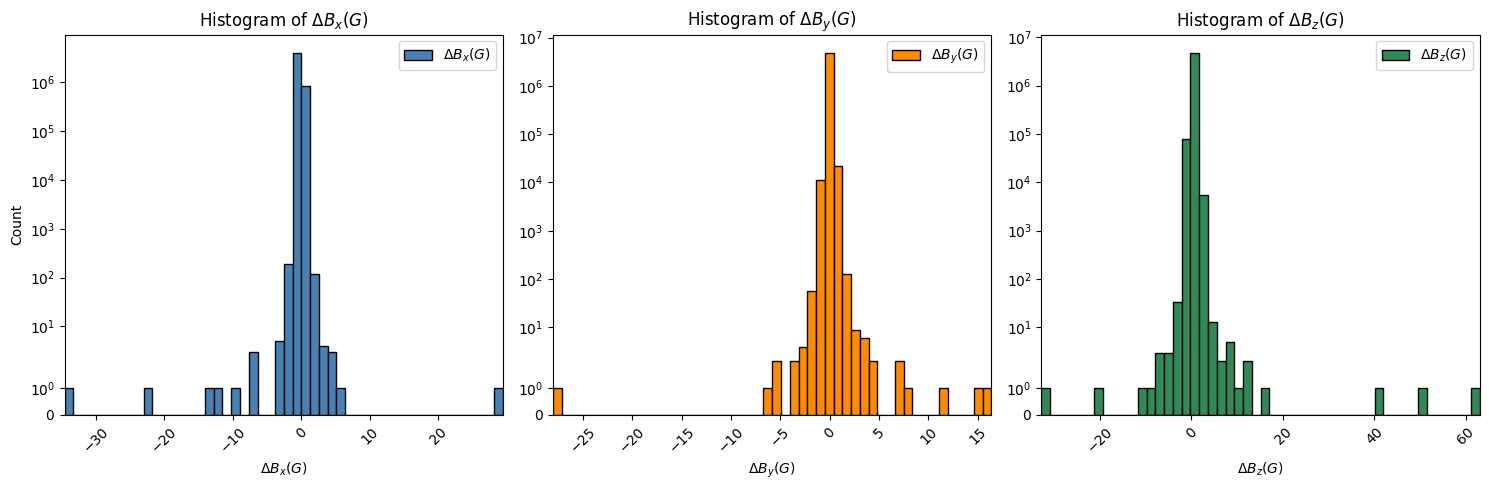

In [14]:
# Plot Differences between my_data and cvmfs_data

#Logarithmic bin setup
linthresh1 = 1e-10
pos_bins = np.logspace(np.log10(linthresh1), np.log10(1e-3), 25)
neg_bins = -pos_bins[::-1]
bins = np.concatenate([neg_bins, pos_bins])

field_data = [field_diff[:, 0], field_diff[:, 1], field_diff[:, 2]]
colors = ["steelblue", "darkorange", "seagreen"]
labels = [r"$\Delta B_x(G)$", r"$\Delta B_y(G)$", r"$\Delta B_z(G)$"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, ax in enumerate(axes):
    ax.hist(field_data[i], bins=50, edgecolor="black", color=colors[i], alpha=1, label=labels[i])
    # ax.set_xscale("symlog")#, linthresh=linthresh1)
    ax.set_yscale("symlog")
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel(labels[i])
    ax.set_xlim(field_data[i].min(), field_data[i].max())
    ax.set_title(f"Histogram of {labels[i]}")
    ax.legend()

axes[0].set_ylabel("Count")

plt.tight_layout()
plt.show()

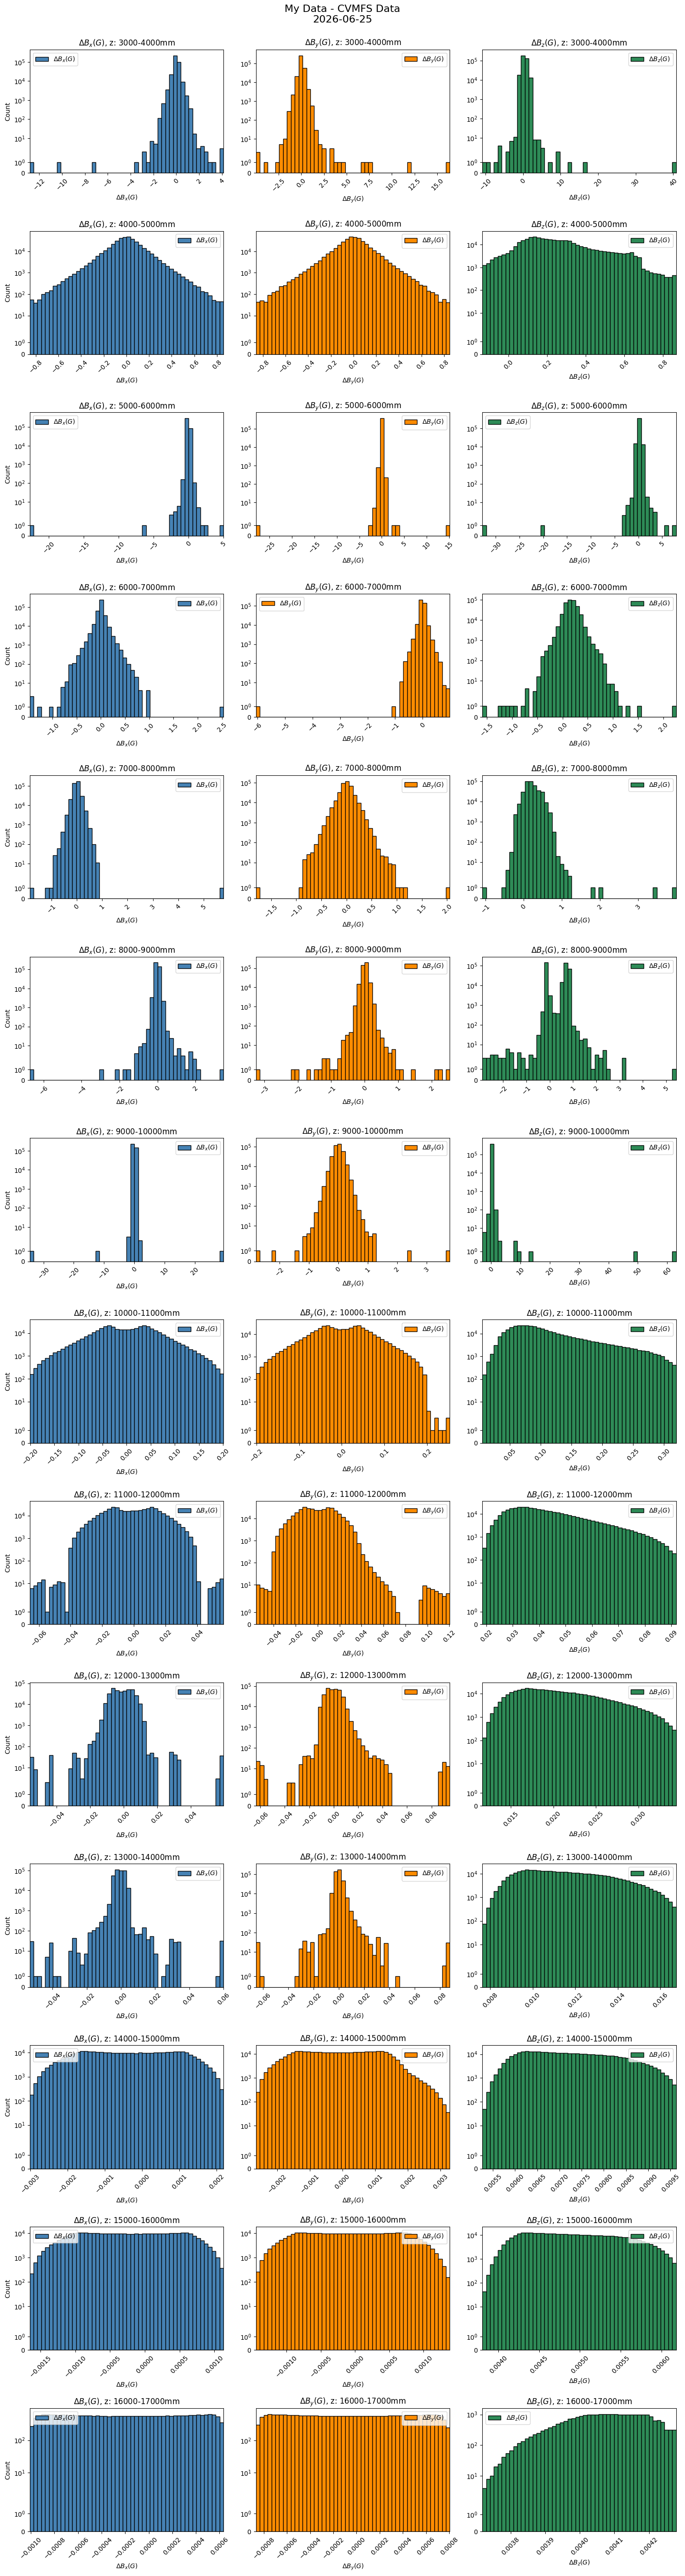

In [15]:
z_coord = cvmfs_coord[:,2]
# print(cvmfs_coord)
# print(z_coord)

linthresh2 = 1e-10
pos_bins = np.logspace(np.log10(linthresh2), np.log10(1e-3), 25)
neg_bins = -pos_bins[::-1]
bins = np.concatenate([neg_bins, pos_bins])

z_ranges = [(i * 1e3, (i + 1) * 1e3) for i in range(3, 17)] # In mm!
colors = ["steelblue", "darkorange", "seagreen"]
labels = [r"$\Delta B_x(G)$", r"$\Delta B_y(G)$", r"$\Delta B_z(G)$"]
# print(z_ranges[0][0])
# mask1 = (z_coord >= z_ranges[0][0]) & (z_coord < z_ranges[0][1])
# mask2 = (z_coord >= z_ranges[1][0]) & (z_coord < z_ranges[1][1])
# mask3 = (z_coord >= z_ranges[2][0]) & (z_coord < z_ranges[2][1])
# print(mask1)

# print(field_diff[mask1])
# print("Field Difference Mask1")
# # print(mask1)
# print(field_diff[mask1])
# print("Field Difference Mask2")
# print(field_diff[mask2])
# print("Field Difference Mask3")
# print(field_diff[mask3])

fig, axes = plt.subplots(len(z_ranges), 3, figsize=(15, 4 * len(z_ranges)))

for row, (lo, hi) in enumerate(z_ranges):
    mask = (z_coord >= lo) & (z_coord < hi)
    fd_slice = field_diff[mask]

    for col in range(3):
        ax = axes[row, col]
        data_col = fd_slice[:, col]

        if data_col.size == 0:
            continue

        ax.hist(data_col, bins=50, edgecolor="black",
                 color=colors[col], alpha=1, label=labels[col])
        # ax.set_xscale("symlog", linthresh=1e-5)
        ax.set_yscale("symlog")
        # ax.set_xticks([-1e-1,-1, 0, 1,1e-1])
        ax.tick_params(axis='x', rotation=45)
        ax.set_xlabel(labels[col])
        ax.set_xlim(data_col.min(), data_col.max())
        ax.set_title(f"{labels[col]}, z: {lo:.0f}-{hi:.0f}mm")
        ax.legend()

    axes[row, 0].set_ylabel("Count")
#Tracker region Z-range: 8540mm - 1181mm
# fig.suptitle(x=0,y=0)
meter_split_title = "My Data - CVMFS Data"+ "\n" + f"{today}"
# r"$\frac{\mathrm{My\ Data} - \mathrm{CVMFS\ Data}}{\mathrm{CVMFS\ Data}}$"+"\n"+"\n"+"Date made: "+f"{today}"
fig.suptitle(meter_split_title, fontsize=16, y=1.0)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.tight_layout()
plt.show()

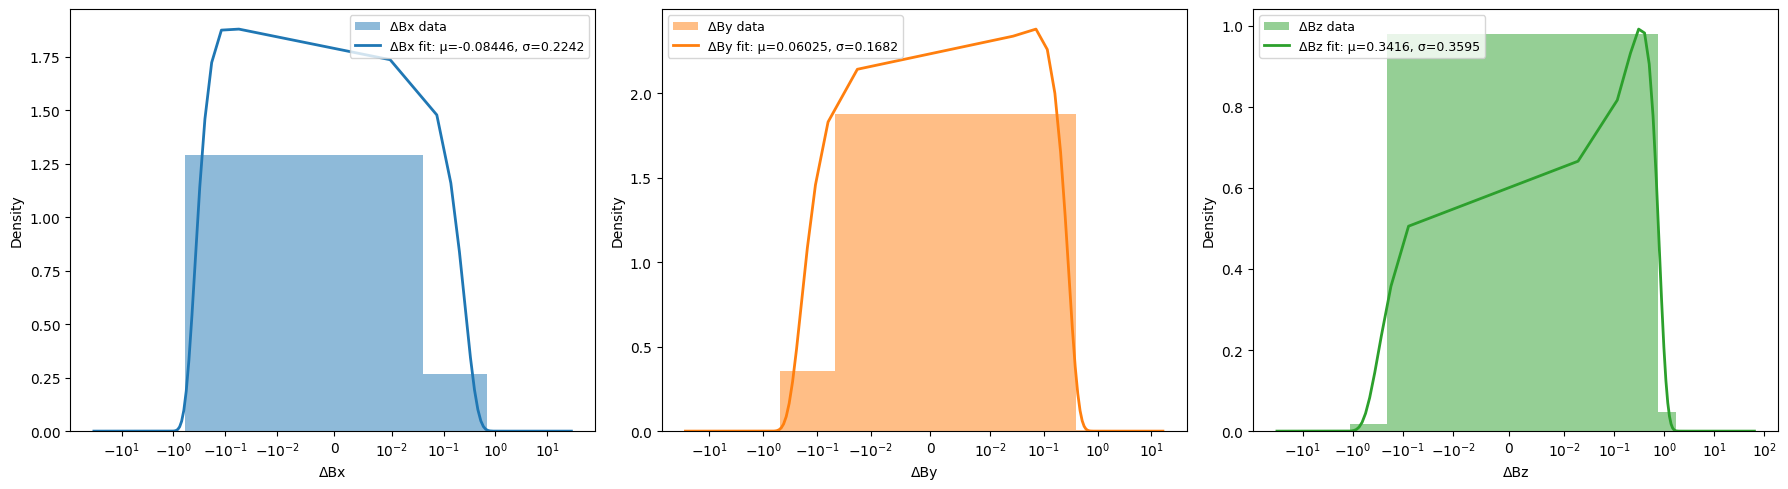

ΔBx: mean = -0.08446 ± 0.0009409, σ = 0.2242 ± 0.0008527
ΔBy: mean = 0.06025 ± 0.0007998, σ = 0.1682 ± 0.0006328
ΔBz: mean = 0.3416 ± 0.0004463, σ = 0.3595 ± 0.0001868


In [16]:
# Example usage for ΔBx, ΔBy, ΔBz
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

results = {}
results['ΔBx'] = fit_and_plot_gaussian(field_data[0], axes[0], 'ΔBx', color='C0')
results['ΔBy'] = fit_and_plot_gaussian(field_data[1], axes[1], 'ΔBy', color='C1')
results['ΔBz'] = fit_and_plot_gaussian(field_data[2], axes[2], 'ΔBz', color='C2')

plt.tight_layout()
plt.show()

# Print fit results
for key, res in results.items():
    if res:
        print(f"{key}: mean = {res['mean']:.4g} ± {res['mean_err']:.4g}, "
      f"σ = {res['sigma']:.4g} ± {res['sigma_err']:.4g}")

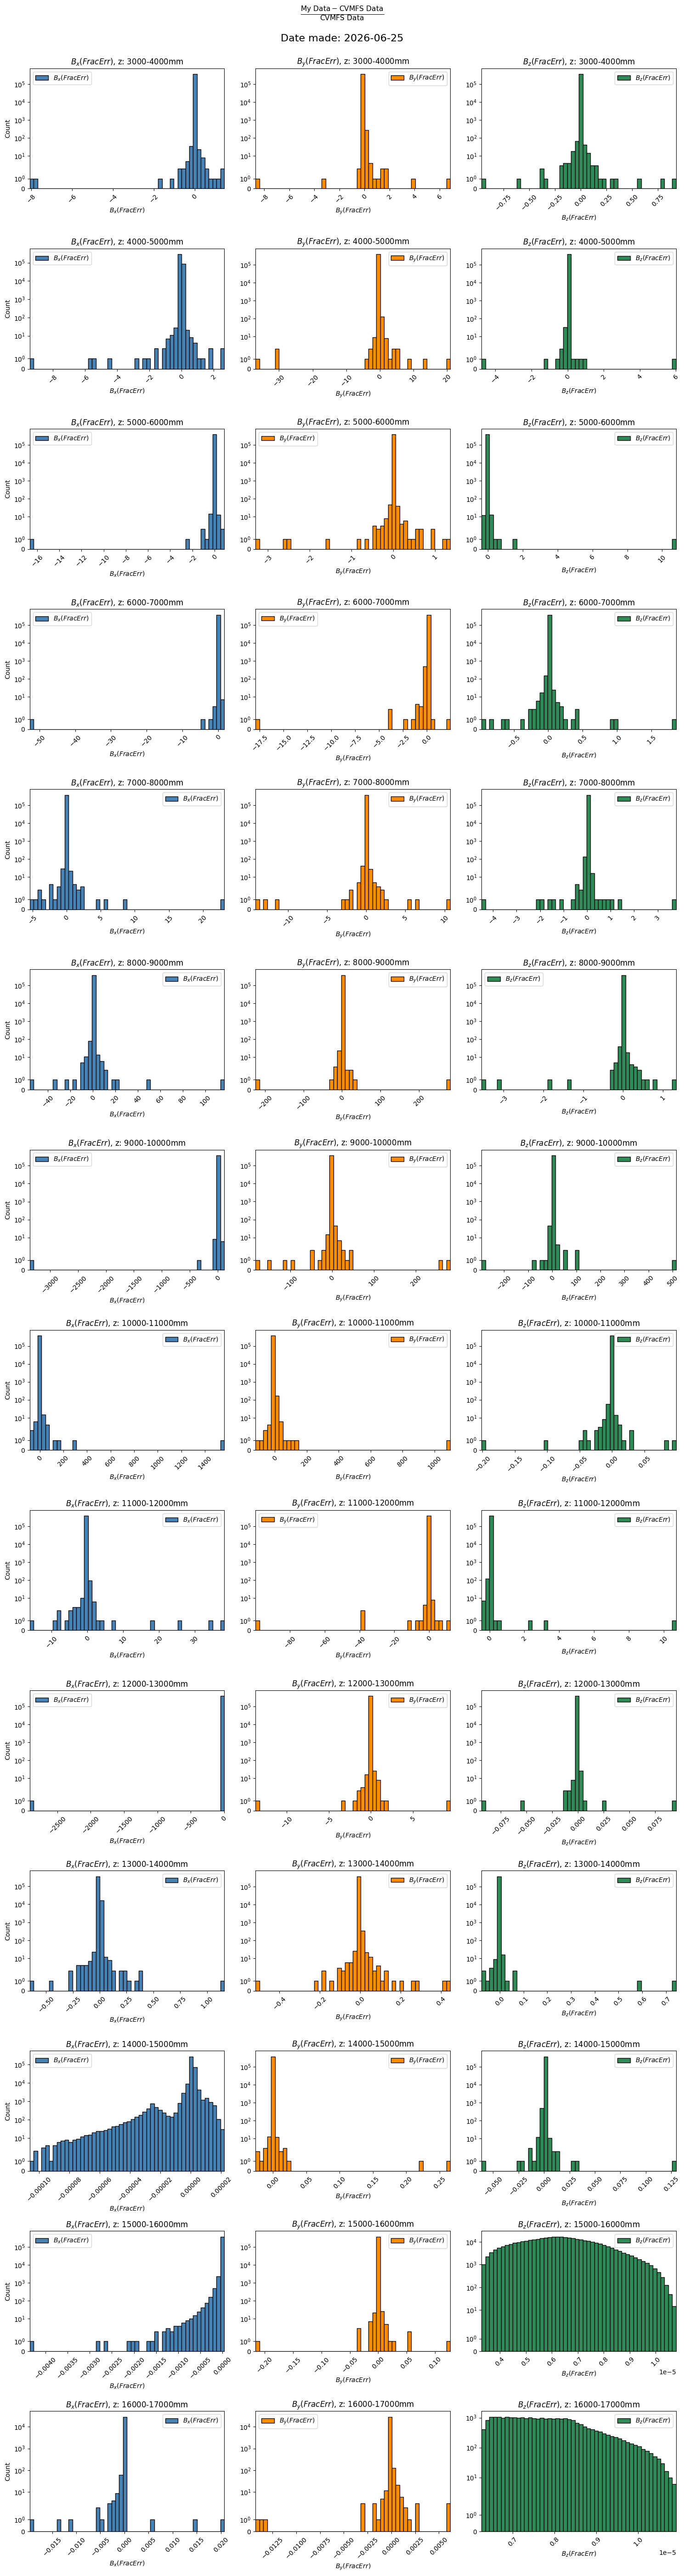

In [17]:
##Fractional Error Plots##

z_coord = cvmfs_coord[:,2]

# linthresh2 = 1e-10
# pos_bins = np.logspace(np.log10(linthresh2), np.log10(1e-3), 25)
# neg_bins = -pos_bins[::-1]
# bins = np.concatenate([neg_bins, pos_bins])

z_ranges = [(i * 1e3, (i + 1) * 1e3) for i in range(3, 17)] # In mm!
colors = ["steelblue", "darkorange", "seagreen"]
labels = [r"$B_x(FracErr)$", r"$B_y(FracErr)$", r"$B_z(FracErr)$"]


fig, axes = plt.subplots(len(z_ranges), 3, figsize=(15, 4 * len(z_ranges)))

for row, (lo, hi) in enumerate(z_ranges):
    mask = (z_coord >= lo) & (z_coord < hi)
    fd_slice = frac_error[mask]

    for col in range(3):
        ax = axes[row, col]
        data_col = fd_slice[:, col]

        if data_col.size == 0:
            continue

        ax.hist(data_col, bins=50, edgecolor="black",
                 color=colors[col], alpha=1, label=labels[col])
        # ax.set_xscale("symlog", linthresh=1e-5)
        ax.set_yscale("symlog")
        ax.tick_params(axis='x', rotation=45)
        ax.set_xlabel(labels[col])
        ax.set_xlim(data_col.min(), data_col.max())
        ax.set_title(f"{labels[col]}, z: {lo:.0f}-{hi:.0f}mm")
        ax.legend()

    axes[row, 0].set_ylabel("Count")

#Tracker region Z-range: 8540mm - 1181mm
fracerror_title = r"$\frac{\mathrm{My\ Data} - \mathrm{CVMFS\ Data}}{\mathrm{CVMFS\ Data}}$"+"\n"+"\n"+"Date made: "+f"{today}"
fig.suptitle(fracerror_title, fontsize=16, y=1.0)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.tight_layout()
plt.show()

/tmp/ipykernel_37091/3987273340.py:38: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(gaussian, bin_centers, counts, p0=p0, maxfev=10000)
/usr/local/lib/python3.12/dist-packages/scipy/optimize/_minpack_py.py:498: RuntimeWarning: overflow encountered in matmul
  cov_x = invR @ invR.T


Fit failed: z=8000-9000mm, component=$B_y(FracErr)$


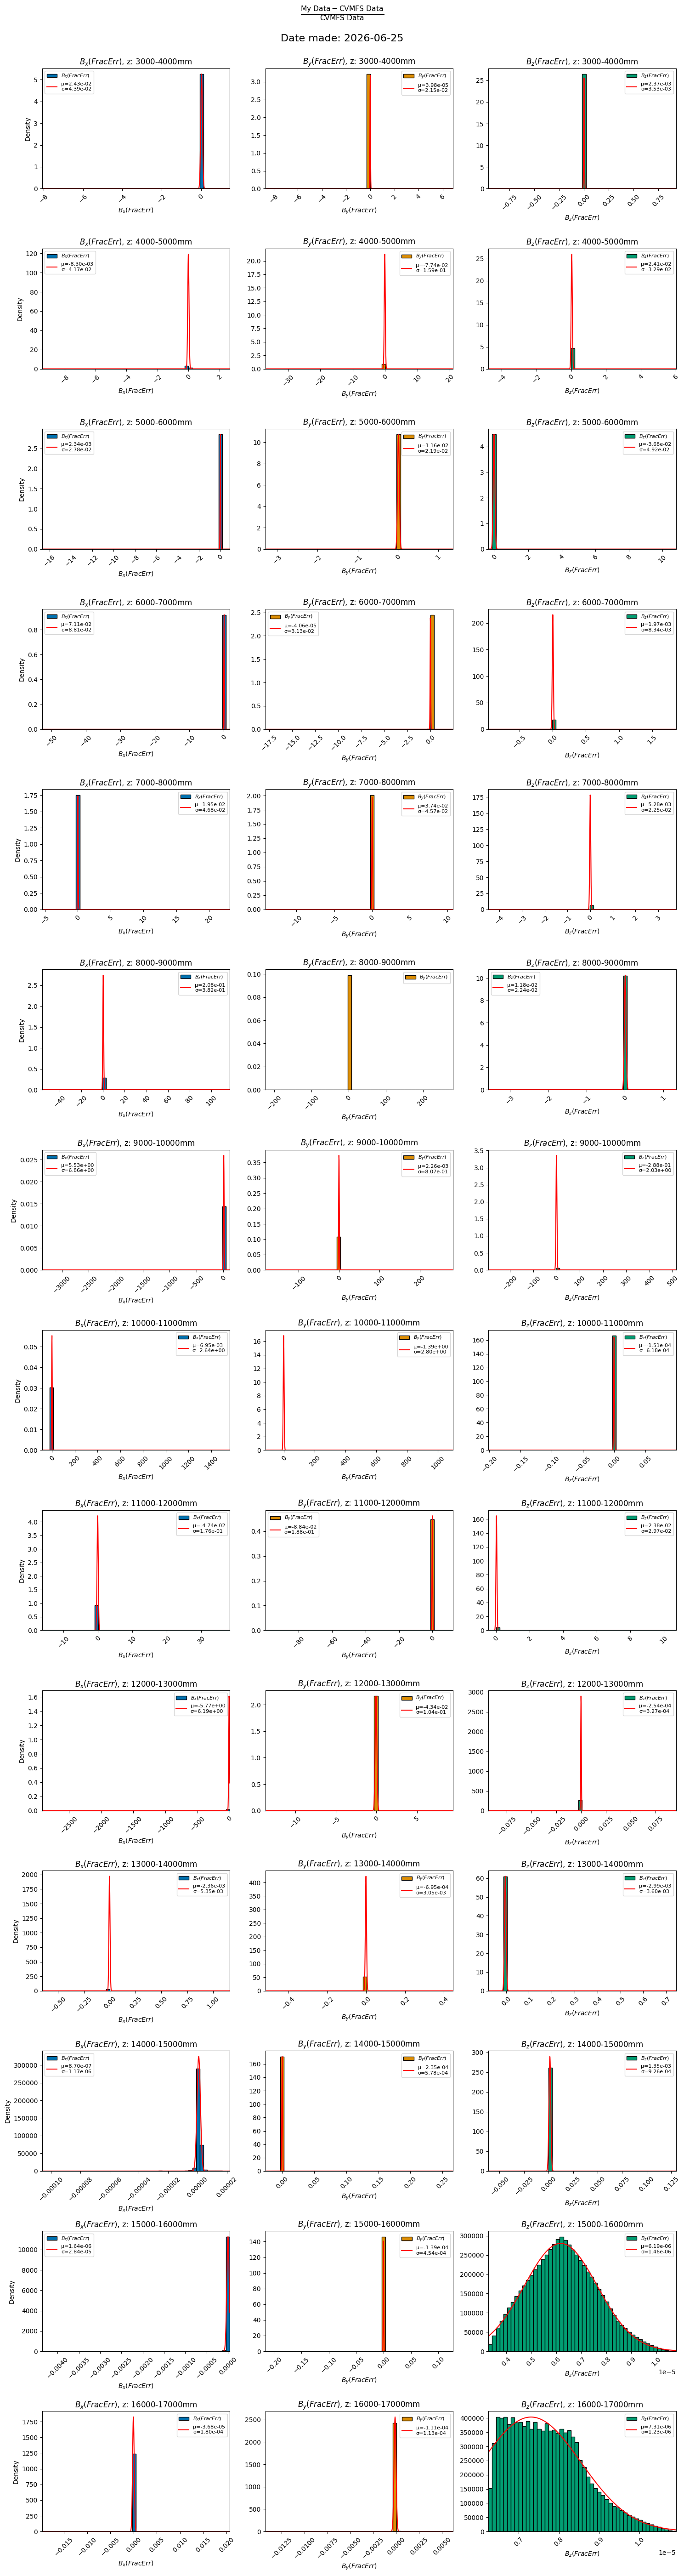

z: 3000-4000mm, $B_x(FracErr)$: μ = 0.02433 ± 0.0003984, σ = 0.04386 ± 9.265e-05
z: 3000-4000mm, $B_y(FracErr)$: μ = 3.976e-05 ± inf, σ = 0.02147 ± inf
z: 3000-4000mm, $B_z(FracErr)$: μ = 0.002366 ± inf, σ = 0.003534 ± inf
z: 4000-5000mm, $B_x(FracErr)$: μ = -0.008302 ± 3.477e+08, σ = 0.04173 ± 8.54e+08
z: 4000-5000mm, $B_y(FracErr)$: μ = -0.07743 ± 1.484e+09, σ = 0.1593 ± 6.735e+08
z: 4000-5000mm, $B_z(FracErr)$: μ = 0.02412 ± 4.712e+05, σ = 0.03285 ± 1.655e+05
z: 5000-6000mm, $B_x(FracErr)$: μ = 0.002341 ± inf, σ = 0.02783 ± inf
z: 5000-6000mm, $B_y(FracErr)$: μ = 0.01158 ± 0.0001567, σ = 0.02187 ± 3.68e-05
z: 5000-6000mm, $B_z(FracErr)$: μ = -0.03681 ± 0.0001793, σ = 0.04923 ± 3.948e-05
z: 6000-7000mm, $B_x(FracErr)$: μ = 0.07113 ± inf, σ = 0.08807 ± inf
z: 6000-7000mm, $B_y(FracErr)$: μ = -4.061e-05 ± inf, σ = 0.03134 ± 5.372e+04
z: 6000-7000mm, $B_z(FracErr)$: μ = 0.001969 ± 3.045e+08, σ = 0.008343 ± 1.323e+08
z: 7000-8000mm, $B_x(FracErr)$: μ = 0.01953 ± inf, σ = 0.04684 ± inf
z:

In [18]:
##Fractional Error Plots with Gaussian Fits##
from scipy.optimize import curve_fit

def gaussian(x, amplitude, mean, sigma):
    return amplitude * np.exp(-(x - mean)**2 / (2 * sigma**2))

z_coord = cvmfs_coord[:,2]

z_ranges = [(i * 1e3, (i + 1) * 1e3) for i in range(3, 17)] # In mm!
# colors = ["steelblue", "darkorange", "seagreen"]
colors = ["#0173B2", "#DE8F05", "#029E73"]
labels = [r"$B_x(FracErr)$", r"$B_y(FracErr)$", r"$B_z(FracErr)$"]

fig, axes = plt.subplots(len(z_ranges), 3, figsize=(15, 4 * len(z_ranges)))

fit_results = {}  # store fit params per (z_range, component)

for row, (lo, hi) in enumerate(z_ranges):
    mask = (z_coord >= lo) & (z_coord < hi)
    fd_slice = frac_error[mask]

    for col in range(3):
        ax = axes[row, col]
        data_col = fd_slice[:, col]
        data_col = data_col[~np.isnan(data_col)]

        if data_col.size == 0:
            continue

        # Histogram (density=True so the Gaussian fit matches the scale)
        counts, bin_edges, _ = ax.hist(data_col, bins=50, edgecolor="black",
                 color=colors[col], alpha=1, label=labels[col], density=True)
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

        # Fit Gaussian
        p0 = [counts.max(), np.mean(data_col), np.std(data_col)]
        try:
            popt, pcov = curve_fit(gaussian, bin_centers, counts, p0=p0, maxfev=10000)
            amplitude, mean, sigma = popt
            perr = np.sqrt(np.diag(pcov))

            x_fit = np.linspace(data_col.min(), data_col.max(), 1000)
            ax.plot(x_fit, gaussian(x_fit, *popt), color='red', linewidth=1.5,
                     label=f'μ={mean:.2e}\nσ={sigma:.2e}')

            fit_results[(lo, hi, col)] = {
                'mean': mean, 'sigma': sigma,
                'mean_err': perr[1], 'sigma_err': perr[2]
            }
        except RuntimeError:
            print(f"Fit failed: z={lo:.0f}-{hi:.0f}mm, component={labels[col]}")

        # ax.set_yscale("symlog")
        ax.tick_params(axis='x', rotation=45)
        ax.set_xlabel(labels[col])
        ax.set_xlim(data_col.min(), data_col.max())
        ax.set_title(f"{labels[col]}, z: {lo:.0f}-{hi:.0f}mm")
        ax.legend(fontsize=8)

    axes[row, 0].set_ylabel("Density")

#Tracker region Z-range: 8540mm - 1181mm
fracerror_title = r"$\frac{\mathrm{My\ Data} - \mathrm{CVMFS\ Data}}{\mathrm{CVMFS\ Data}}$"+"\n"+"\n"+"Date made: "+f"{today}"
fig.suptitle(fracerror_title, fontsize=16, y=1.0)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.tight_layout()
plt.show()

# Print all fit results
for (lo, hi, col), res in fit_results.items():
    print(f"z: {lo:.0f}-{hi:.0f}mm, {labels[col]}: "
          f"μ = {res['mean']:.4g} ± {res['mean_err']:.4g}, "
          f"σ = {res['sigma']:.4g} ± {res['sigma_err']:.4g}")

# Analyze Field Gradients

In [19]:
step = 0.25  # in meters
z_starts = np.arange(8500, 9000, step)
z_ranges = [(z * 1e3, (z + step) * 1e3) for z in z_starts]
def make_isosurface(data, value_col, title, colorscale='Viridis',
                     n_isomin_pct=10, n_isomax_pct=90, surface_count=15,
                     max_points=200_000):
    """
    Build a 3D isosurface/volume plot of `value_col` for a single slice of data.
    """
    data = data[['X', 'Y', 'Z', value_col]].dropna()

    if len(data) == 0:
        return None

    if len(data) > max_points:
        data = data.sample(max_points, random_state=42)

    vmin = np.percentile(data[value_col], n_isomin_pct)
    vmax = np.percentile(data[value_col], n_isomax_pct)

    # Guard against flat/degenerate slices
    if vmin == vmax:
        return None
    units = "G"
    fig = go.Figure(data=go.Isosurface(
        x=data['X'],
        y=data['Y'],
        z=data['Z'],
        value=data[value_col],
        isomin=vmin,
        isomax=vmax,
        surface_count=surface_count,
        colorscale=colorscale,
        caps=dict(x_show=False, y_show=False, z_show=False),
        colorbar=dict(
            title=dict(text=f"{value_col} ({units})", side="right")
    )))

    fig.update_layout(
        title=title,
        scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z'),
        width=900,
        height=700
    )

    return fig


def plot_isosurfaces_by_zslice(df, value_col, colorscale, z_ranges):
    df['Bmag'] = np.sqrt(df['Bx']**2 + df['By']**2 + df['Bz']**2) if value_col == 'Bmag' else df.get('Bmag')

    figs = []
    for z_min, z_max in z_ranges:
        slice_df = df[(df['Z'] >= z_min) & (df['Z'] < z_max)]

        title = f"{value_col} Isosurface | Z: {z_min:.3f}-{z_max:.3f} "
        fig = make_isosurface(slice_df, value_col, title=title, colorscale=colorscale)

        if fig is not None:
            figs.append(fig)
            fig.show()
        else:
            print(f"Skipped Z range {z_min}-{z_max} (no data or flat slice)")

    return figs

# print(type(field_data))

field_data = pd.DataFrame({
    'X': cvmfs_coord[:, 0],
    'Y': cvmfs_coord[:, 1],
    'Z': cvmfs_coord[:, 2],
    'Bx': mydata_field[:, 0],
    'By': mydata_field[:, 1],
    'Bz': mydata_field[:, 2],
})
# print(field_data)

# ----- Compute magnitude once -----
# field_data['Bmag'] = np.sqrt(field_data['Bx']**2 + field_data['By']**2 + field_data['Bz']**2)
# print(field_data)
# print(field_data['Z'].min(), field_data['Z'].max())
# print(field_data['Z'].describe())
# ----- Run for each component -----
figs_bmag = plot_isosurfaces_by_zslice(field_data, 'Bmag', 'Viridis', z_ranges)
# figs_bx   = plot_isosurfaces_by_zslice(field_data, 'Bx', 'RdBu', z_ranges)
# figs_by   = plot_isosurfaces_by_zslice(field_data, 'By', 'RdBu', z_ranges)
# figs_bz   = plot_isosurfaces_by_zslice(field_data, 'Bz', 'RdBu', z_ranges)

SyntaxError: invalid syntax (257738758.py, line 2)

# Scratch: Remember to comment out anything below

In [ ]:
# # Load first file as base
# df1 = load_pkl(Data_file[0])
# df2 = load_pkl(Data_file[1])
# df3 = load_pkl(Helicalc_file[0])
# df4 = load_pkl(Helicalc_file[1])
# coord_cols = df1.columns[[0,1,2,6,7]].tolist()
# field_cols = df1.columns[[3,4,5,8,9]].tolist()
# DS_PS_Map_Append = pd.concat([df1, df2], ignore_index=True)
# print(DS_PS_Map_Append)
# print("Summing:", field_cols)
# # summed_field = df1[field_cols] + df2[field_cols]
# # print(summed_field)
# merged = df1.merge(df2, on = coord_cols, how = 'outer', suffixes = ('_a', '_b'))
# print('Checking for overlap')
# common = df1.merge(df2, on=coord_cols, how='inner')
# print(f"Overlapping rows: {common.shape}")
# print('Merged')
# print(merged)
# for col in field_cols:
#   merged[col] = merged[f'{col}_a'].add(merged[f'{col}_b'], fill_value = 0)

# summed_field = merged[df1.columns.tolist()]
# print('Summed Fields')
# print(summed_field.shape)
# print(summed_field)
# print('###DS Map###')
# print(Data_file[0])
# print(df1)
# # print(df1.iloc[:, [3,4,5,8,9]])
# print('###PS Map###')
# print(df2)
# print(Data_file[1])
# # print(df2.iloc[:, [3,4,5,8,9]])
# # print(Helicalc_file[0])
# # print(df3.head())
# # print(Helicalc_file[1])
# # print(df4.head())

# # for d in Helicalc_file:
# #   load_pkl(Helicalc_file)


# # print(summed_field.head())
# # print(df1[coord_cols].equals(df2[coord_cols]))
# # for fpath in Data_file[1:]:
# #     df = load_pkl(fpath)
# #     # Merge on coordinates
# #     merged = result.merge(df, on=coord_cols, suffixes=('_a', '_b'))
# #     # Sum field components
# #     for col in field_cols:
# #         merged[col] = merged[f'{col}_a'] + merged[f'{col}_b']
# #     # Keep only original columns
# #     result = merged[['X', 'Y', 'Z', 'Bx', 'By', 'Bz', 'R', 'Phi', 'Br', 'Bphi']]

# # # Save
# # with open(output_path, "wb") as f:
# #     pickle.dump(result, f)

# # print(f"Final shape: {result.shape}")
# # print(result.head())

# common = df1.merge(df2, on=['X','Y','Z'], how='inner')
# print(f"Matching XYZ rows: {common.shape[0]}")

In [ ]:
# coord_cols = ['X', 'Y', 'Z']
# field_cols = ['Bx', 'By', 'Bz']

# output_path = os.path.join(helicalc_path, "busbar_summed.pkl")

# result = None
# for fname in helicalc_partial_pkl_array:
#     fpath = os.path.join(helicalc_path, fname)
#     df = load_pkl(fpath)

#     # Rename field cols by position
#     cols = df.columns.tolist()
#     cols[3] = 'Bx'
#     cols[4] = 'By'
#     cols[5] = 'Bz'
#     df.columns = cols

#     if result is None:
#         result = df
#     else:
#         merged = result.merge(df, on=coord_cols, how='outer', suffixes=('_a', '_b'))
#         for col in field_cols:
#             merged[col] = merged[f'{col}_a'].add(merged[f'{col}_b'], fill_value=0)
#         result = merged[result.columns.tolist()]

# with open(output_path, "wb") as f:
#     pickle.dump(result, f)

# txt_path = os.path.join(helicalc_path, "busbar_summed.txt")
# result.to_csv(txt_path, sep='/', index=False)

# print(f"Saved to {output_path}")
# print(f"Saved to {txt_path}")

# # print('helicalc_result')
# # print(helicalc_result)


# # merged = df1.merge(df2, on = coord_cols, how = 'outer', suffixes = ('_a', '_b'))
# # print('Checking for overlap')
# # common = df1.merge(df2, on=coord_cols, how='inner')
# # print(f"Overlapping rows: {common.shape}")
# # print('Merged')
# # print(merged)
# # for col in field_cols:
# #   merged[col] = merged[f'{col}_a'].add(merged[f'{col}_b'], fill_value = 0)


In [ ]:
# print(Solcalc_file)
# for i, fpath in enumerate(Solcalc_file):
#   df = load_pkl(fpath)
#   # print(i, df.shape)
#   print(f"/n{fpath}")
#   for col in ['X','Y','Z']:
#     print(f" {col}: {df[col].min()} to {df[col].max()}")



# print(Solcalc_file)
# # print(2.696-1.2)

# for i, fpath in enumerate(Solcalc_file):
#   df = load_pkl(fpath)
#   # print(i, df.shape)
#   print(f"/n{fpath}")
#   for col in ['X','Y','Z']:
#     print(f" {col}: {df[col].min()} to {df[col].max()}")

# # helicalc_fs = [load_pkl(f) for f in Helicalc_file]
# # helicalc_result = helicalc_fs[0]
# # coord_cols = helicalc_result.columns[[0,1,2]].tolist()
# # field_cols = helicalc_result.columns[[3,4,5]].tolist()

# coord_cols = ['X', 'Y', 'Z']
# field_cols = ['Bx', 'By', 'Bz']

# output_path = os.path.join(helicalc_path, "busbar_summed.pkl")

# result = None
# for fname in helicalc_partial_pkl_array:
#     fpath = os.path.join(helicalc_path, fname)
#     df = load_pkl(fpath)

#     # Rename field cols by position
#     cols = df.columns.tolist()
#     cols[3] = 'Bx'
#     cols[4] = 'By'
#     cols[5] = 'Bz'
#     df.columns = cols

#     if result is None:
#         result = df
#     else:
#         merged = result.merge(df, on=coord_cols, how='outer', suffixes=('_a', '_b'))
#         for col in field_cols:
#             merged[col] = merged[f'{col}_a'].add(merged[f'{col}_b'], fill_value=0)
#         result = merged[result.columns.tolist()]

# with open(output_path, "wb") as f:
#     pickle.dump(result, f)

# txt_path = os.path.join(helicalc_path, "busbar_summed.txt")
# result.to_csv(txt_path, sep='/', index=False)

# print(f"Saved to {output_path}")
# print(f"Saved to {txt_path}")

In [ ]:
# import pickle
# import pandas as pd
# import os

# ##Create Some Definitions##
# def pkl_2_txt(pkl_file):
#     with open('pkl_file', 'rb') as f:
#         data = pickle.load(f)
#     print(data)


# def store_pkl_2_txt(pkl_file):
#     with open('pkl_file', 'rb') as f:
#         data = pickle.load(f)

#     # txt_file = pkl_file.replace(".pkl", ".txt")

#     with open (txt_file, 'x') as f:
#         f.write(str(data))



# with open(DSMap_pkl, "rb") as f:
#     data = pickle.load(f)

# # print(type(data))
# # print(data)


# # ##Test Create DS+PS Map##
# # result = None
# # def load_pkl(filepath):
# #   with open(filepath, "rb") as f:
# #     return pickle.load(f)
# # output_path = os.path.join(data_path, "DS+PS_Map.pkl")
# # for fname in data_pkl_array:
# #   fpath = os.path.join(data_path, fname)
# #   df = load_pkl(fpath)
# #   result = df if result is None else result.add(df)

# # with open(output_path, "wb") as f:
# #   pickle.dump(result, f)
# # print(f"Saved to {output_path}")

# ##DS+PS Did not work, need to fix the ##
# # df1 = load_pkl(os.path.join(data_path, Data_file[0]))
# # df2 = load_pkl(os.path.join(data_path, Data_file[1]))

# print(df1.head())
# print(df1.columns.tolist())
# print(df1.shape)

# print(df2.head())
# print(df2.columns.tolist())
# print(df2.shape)

# print(Data_file)

In [ ]:
# print(Data_file[0])
# with open(data_path+"/"+"DS+PS_Map.pkl", "rb") as f:
#     data = pickle.load(f)

# print(type(data))
# print(data)
# print(df1[coord_cols])
# print(df2[coord_cols])
# print(df3[coord_cols])

In [ ]:
# helicalc_partial_pkl_array = ["Mu2e_V13.DS_region.standard-busbar.cond_N_1_arc.pkl",
#                               "Mu2e_V13.DS_region.standard-busbar.cond_N_2_arc.pkl",
#                               "Mu2e_V13.DS_region.standard-busbar.cond_N_3_arc.pkl",
#                               "Mu2e_V13.DS_region.standard-busbar.cond_N_3_arc.pkl",
#                               "Mu2e_V13.DS_region.standard-busbar.cond_N_4_arc.pkl",
#                               "Mu2e_V13.DS_region.standard-busbar.cond_N_5_arc.pkl",
#                               "Mu2e_V13.DS_region.standard-busbar.cond_N_6_arc.pkl",
#                               "Mu2e_V13.DS_region.standard-busbar.cond_N_7_arc.pkl",
#                               "Mu2e_V13.DS_region.standard-busbar.cond_N_12_straight.pkl",
#                               "Mu2e_V13.DS_region.standard-busbar.cond_N_25_straight.pkl",
#                               "Mu2e_V13.DS_region.standard-busbar.cond_N_26_straight.pkl",
#                               "Mu2e_V13.DS_region.standard-busbar.cond_N_27_straight.pkl",
#                               "Mu2e_V13.DS_region.standard-busbar.cond_N_28_straight.pkl",
#                               "Mu2e_V13.DS_region.standard-busbar.cond_N_29_straight.pkl",
#                               "Mu2e_V13.DS_region.standard-busbar.cond_N_30_straight.pkl",
#                               "Mu2e_V13.DS_region.standard-busbar.cond_N_31_straight.pkl",
#                               "Mu2e_V13.DS_region.standard-busbar.cond_N_32_straight.pkl",
#                               "Mu2e_V13.DS_region.standard-busbar.cond_N_33_straight.pkl",
#                               "Mu2e_V13.DS_region.standard-busbar.cond_N_34_straight.pkl",
#                               "Mu2e_V13.DS_region.standard-helicalc.coil_56_interlayer.pkl",
#                               "Mu2e_V13.DS_region.standard-helicalc.coil_56_layer_1.pkl",
#                               "Mu2e_V13.DS_region.standard-helicalc.coil_56_layer_2.pkl",
#                               "Mu2e_V13.DS_region.standard-helicalc.coil_57_interlayer.pkl",
#                               "Mu2e_V13.DS_region.standard-helicalc.coil_60_layer_1.pkl",
#                               "Mu2e_V13.DS_region.standard-helicalc.coil_63_layer_1.pkl"
# ]

In [ ]:
# if __name__=='__main__':
#     # parse command line arguments
#     parser = argparse.ArgumentParser()
#     parser.add_argument('-xs', '--XShift',
#                         help='How much do you want to shift the x- '+
#                         '["DS"(default), "TSd", "DSCylFMS", "DSCylFMSAll", "DSCylFine"]')
#     parser.add_argument('-C', '--Conductor',
#                         help='Conductor number [12, 25-67], default is 12 '+
#                         '(from Gap DS7-8 to over DS-2).')
#     parser.add_argument('-D', '--Device',
#                         help='Which GPU to use? [0 (default), 1, 2, 3].')
#     parser.add_argument('-j', '--Jacobian',
#                         help='Include points for calculating '+
#                         'the Jacobian of the field? "n"(default)/"y"')
#     parser.add_argument('-d', '--dxyz_Jacobian',
#                         help='What step size (in m) to use for points used in '+
#                         'the Jacobian calculation? e.g. "0.001" (default)')
#     parser.add_argument('-t', '--Testing',
#                         help='Calculate using small subset of field points '+
#                         ' (N=100000)? "y"/"n"(default).')
#     parser.add_argument('-i', '--infile', help='pickle file with coordinate grid')
#     args = parser.parse_args()
#     # fill defaults where needed
#     if args.Region is None:
#         args.Region = 'DS'
#     else:
#         args.Region = args.Region.strip()
#     reg = args.Region